In [2]:
import sys
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [4]:
import numpy as np
import networkx as nx
from sksparse.cholmod import cholesky as sparse_cholesky

In [9]:
edges, n_vertices, weights = load_graph(r"../../data/raw/oregon1_010526.txt")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/oregon1_010526.txt
  Vertices : 11174
  Edges    : 23409
  Weighted : no

n_vertices=11174, edges=23409


In [11]:
check_connectivity(edges, n_vertices)

Components: 1
  -> Graph is fully connected, safe to proceed



1

In [13]:
# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

# 4. Phase 2 — sparse from the start, given graph size
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 11174 x 11174
  Degree range: [1, 2389]
  Non-zeros in L: 57992

✓ lambda_min = 0.032899
  (eigenvalues found: [0.         0.03289937])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


In [16]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [20]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

In [22]:
diameter

10

In [28]:
check_boundary_fraction(gamma_in, gamma_out, n_vertices)

gamma_in: 11, gamma_out: 92, n_vertices: 11174
Boundary fraction: 0.9218%
  -> Likely safe for aggregation (comparable to validated successes).


0.009217827098621801

In [34]:
aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)

In [37]:
summary = summarize_aggregation(aggregate_of, n_coarse, gamma_in, gamma_out)

n_coarse: 6115 (6115 aggregates)
Size distribution -- min: 1, max: 10, mean: 1.83
Singletons: 4483 (73.3%)
gamma_in_coarse: 6, gamma_out_coarse: 74
Overlap (must be empty): set()
Interior coarse vertices: 6035 (98.7%)


In [40]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

gamma_in: 11, gamma_out: 92, n_vertices: 11174
Boundary fraction: 0.9218%
  -> Likely safe for aggregation (comparable to validated successes).
n_coarse: 6115 (6115 aggregates)
Size distribution -- min: 1, max: 10, mean: 1.83
Singletons: 4483 (73.3%)
gamma_in_coarse: 6, gamma_out_coarse: 74
Overlap (must be empty): set()
Interior coarse vertices: 6035 (98.7%)
coarse edges: 16624 (from 23409 fine edges)


In [46]:
result = run_paired_validation(setup, N=100)

N = 100 paired samples
Q_fine   : mean=17.057662  var=0.099102
Q_coarse : mean=19.825242  var=0.144558
Q_fine - Q_coarse : mean=-2.767580  var=0.005292
Correlation(Q_fine, Q_coarse): 0.9958
Variance reduction: 18.73x


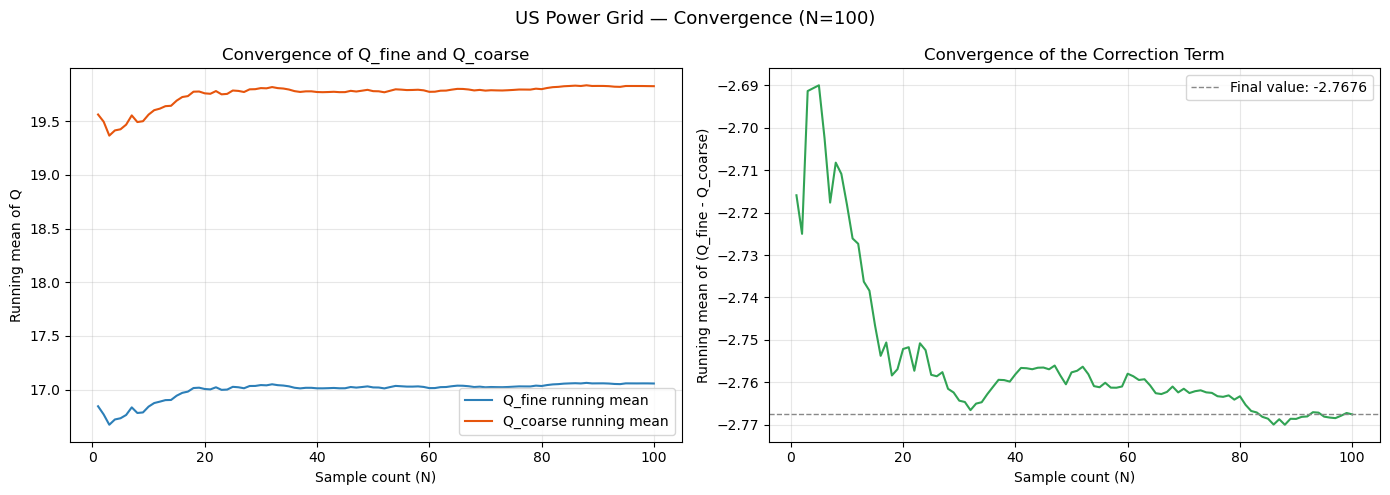

In [51]:
plot_convergence(result, title="US Power Grid — Convergence (N=100)")

In [54]:
estimate = two_level_estimate(setup, result, N_coarse_only=200)

Coarse-only base estimate (N=200): 19.780969
Correction term mean (paired samples): -2.767580
Two-level estimate of E[Q_fine]: 17.013389
Direct fine-only mean (for comparison): 17.057662
